<a href="https://colab.research.google.com/github/Manish927/EDA-Data-Science/blob/main/CNN_Waste_Segregation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [ ]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [1]:
# Import essential libraries

# Core libraries
import numpy as np; import pandas as pd; import matplotlib.pyplot as plt
import seaborn as sns;

# Image processing
import PIL;
import os;

# train and split
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.models import Sequential, load_model

# Callbacks & optimizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("Num GPUs:", len(tf.config.list_physical_devices('GPU')))

Num GPUs: 0


Load the dataset.

In [ ]:
# Load and unzip the dataset
!unzip /content/data.zip


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [3]:
# Create a function to load the raw images
def load_image(image_path, img_size=(224,224)):
  try:
    img = PIL.Image.open(image_path)
    # Convert to RGB
    # CNN expects 3 channels consistently
    img = img.convert('RGB')
    # Convert to numpy array
    img_array = np.array(img)
    return img_array
  except Exception as e:
    print(f"Error loading image: {image_path}")
    return None


#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [4]:
# Get the images and their labels
data_dir = r'/content/data'
images = []
labels = []

class_names = sorted(os.listdir(data_dir))
print('Classes: ', class_names)

# Create label mapping
label_map = {class_name: i for i, class_name in enumerate(class_names)}
print("Label Mapping:", label_map)

# Iterate through folders
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
      print(f'Loading images from {class_path}...')

      for i, img_file in enumerate(os.listdir(class_path)):
        img_path = os.path.join(class_path, img_file)
        img = load_image(img_path)

        if img is not None:
          images.append(img)
          labels.append(label_map[class_name])

# Convert to numpy arrays
X = images
y = np.array(labels)

print('Total images:', len(X))
print('y shape:', y.shape)

Classes:  ['Cardboard', 'Food_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']
Label Mapping: {'Cardboard': 0, 'Food_Waste': 1, 'Glass': 2, 'Metal': 3, 'Other': 4, 'Paper': 5, 'Plastic': 6}
Loading images from /content/data/Cardboard...
Loading images from /content/data/Food_Waste...
Loading images from /content/data/Glass...
Loading images from /content/data/Metal...
Loading images from /content/data/Other...
Loading images from /content/data/Paper...
Loading images from /content/data/Plastic...
Total images: 7625
y shape: (7625,)


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Cardboard'),
  Text(1, 0, 'Food_Waste'),
  Text(2, 0, 'Glass'),
  Text(3, 0, 'Metal'),
  Text(4, 0, 'Other'),
  Text(5, 0, 'Paper'),
  Text(6, 0, 'Plastic')])

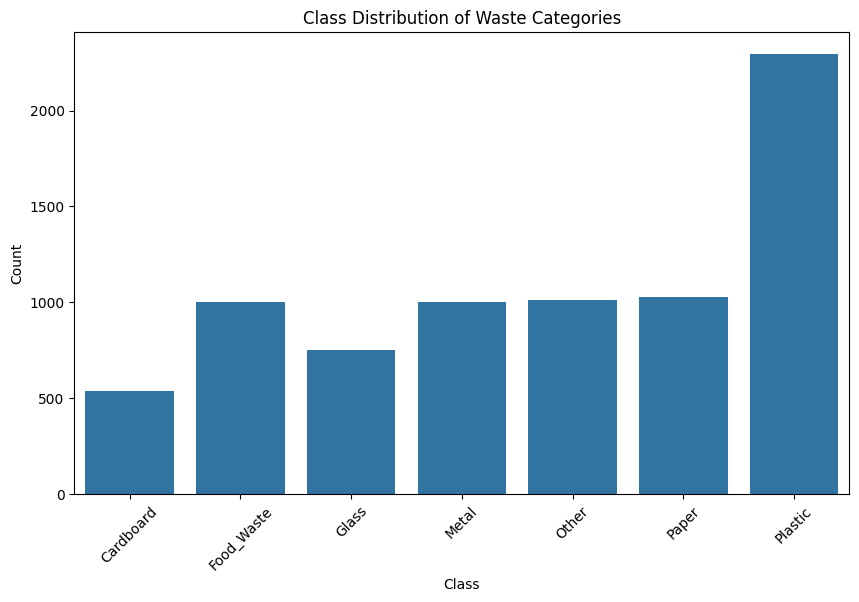

In [5]:
# Visualise Data Distribution
# Count samples per class

class_counts = pd.Series(y).value_counts().sort_index()

# Map indices to class names
class_labels = [class_names[i] for i in class_counts.index]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=class_labels, y=class_counts.values)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution of Waste Categories')
plt.xticks(rotation=45)

In [6]:
# Show percentage distribution
class_percent = (class_counts / class_counts.sum()) * 100
print(class_percent)

0     7.081967
1    13.114754
2     9.836066
3    13.114754
4    13.245902
5    13.508197
6    30.098361
Name: count, dtype: float64


#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

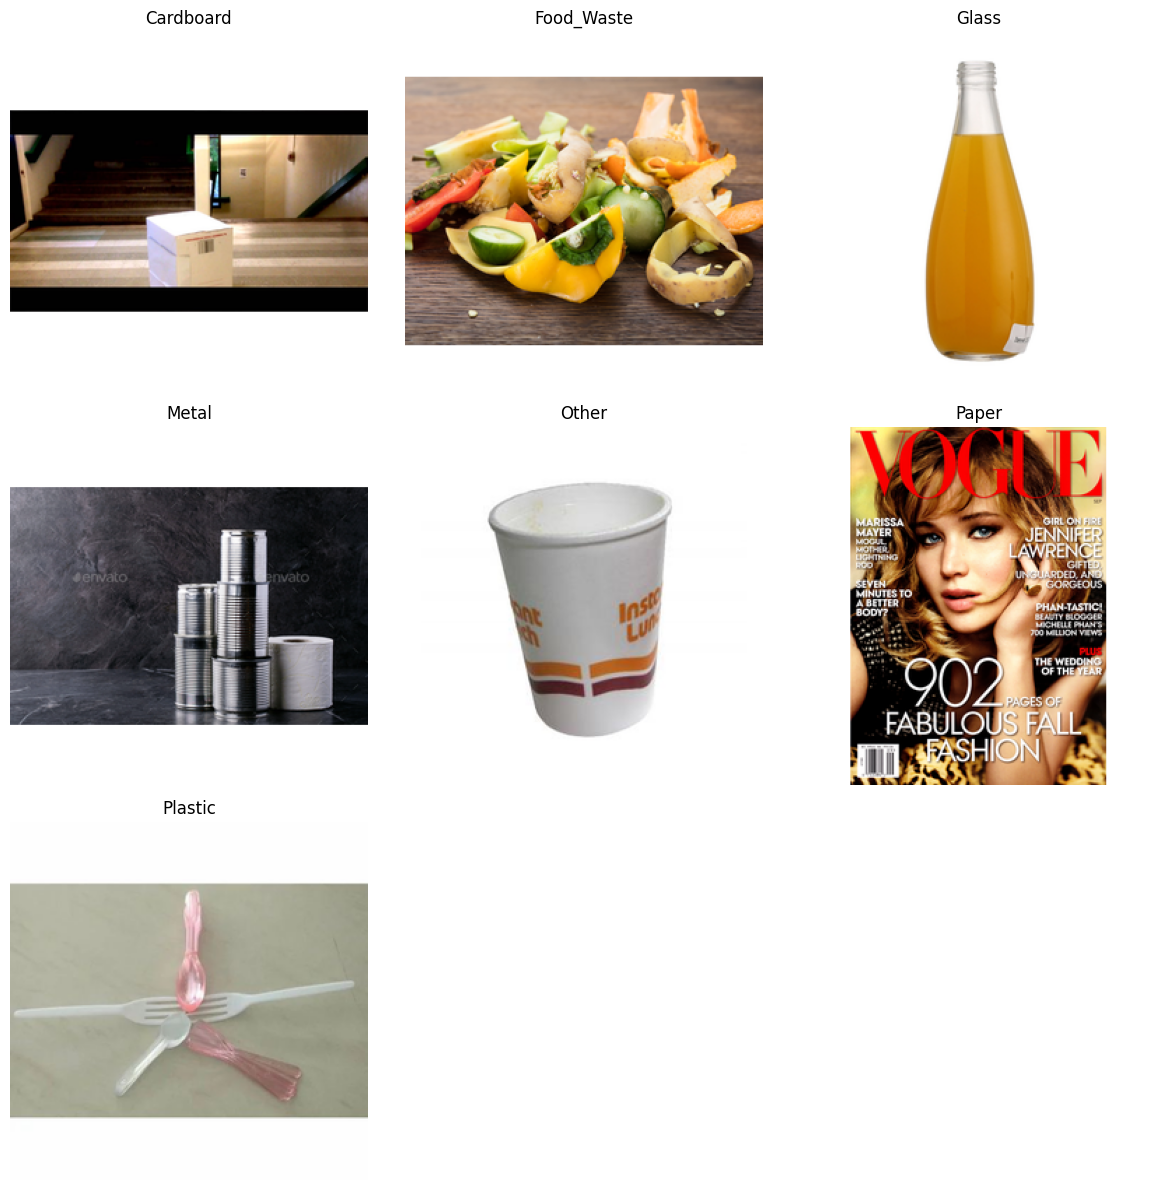

In [6]:
# Visualise Sample Images (across different labels)
plt.figure(figsize=(12, 12))

for class_idx in range(len(class_names)):
    indices = np.where(y == class_idx)[0]

    # Random image from each class
    img_index = np.random.choice(indices)

    plt.subplot(3, 3, class_idx + 1)
    plt.imshow(X[img_index])
    plt.title(class_names[class_idx])
    plt.axis("off")

plt.tight_layout()
plt.show()

#“During EDA, I found some noisy or irrelevant images in certain classes,
# which can negatively impact model performance.
# This indicates real-world dataset imperfections.”

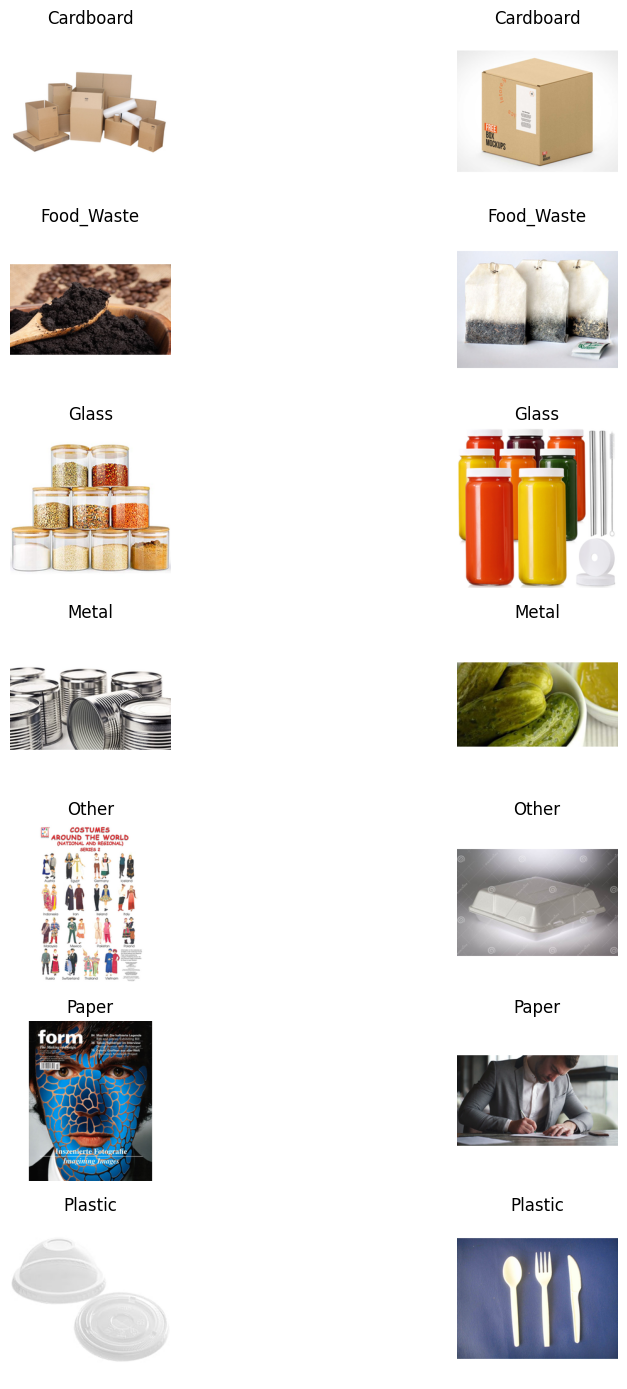

In [7]:
samples_per_class = 2

plt.figure(figsize=(12, 14))
plot_idx = 1

for class_idx in range(len(class_names)):
    indices = np.where(y == class_idx)[0]

    for i in range(samples_per_class):
        img_index = np.random.choice(indices)

        plt.subplot(len(class_names), samples_per_class, plot_idx)
        plt.imshow(X[img_index])
        plt.title(class_names[class_idx])
        plt.axis("off")

        plot_idx += 1

plt.tight_layout()
plt.show()

#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [7]:
# Find the smallest and largest image dimensions from the data set


min_width, min_height = float('inf'), float('inf')
max_width, max_height = 0, 0

for img in X:
    height, width, _ = img.shape

    min_width = min(min_width, width)
    min_height = min(min_height, height)

    max_width = max(max_width, width)
    max_height = max(max_height, height)

print(f"Smallest Image Size: ({min_width}, {min_height})")
print(f"Largest Image Size: ({max_width}, {max_height})")


Smallest Image Size: (256, 256)
Largest Image Size: (256, 256)


In [8]:
# I find all the images are already uniform Height = 256, Width = 256 and Channels = 3(RGB)
for i in range(5):
    img = PIL.Image.open(os.path.join(data_dir, class_names[0], os.listdir(os.path.join(data_dir, class_names[0]))[i]))
    print(img.size)  # (width, height)

unique_shapes = set()

for img in X:
    unique_shapes.add(img.shape)

print("Unique shapes:", unique_shapes)

(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)
Unique shapes: {(256, 256, 3)}


In [9]:
# Resize the image dimensions

# Although all images are already of size 256x256, but colab crash using 150X150
# we resize them to 224x224 for compatibility with standard CNN architectures
# and to reduce computational cost.

X_resized = []

for img in X:
    img_pil = PIL.Image.fromarray(img)
    img_resized = img_pil.resize((224, 224))
    X_resized.append(np.array(img_resized))

X_resized = np.array(X_resized)
X_resized.shape

(7625, 224, 224, 3)

### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [10]:
# Encode the labels suitably

# Encode labels (already done via label_map)
y_encoded = np.array(labels)

print("Encoded labels shape:", y_encoded.shape)
print("Sample labels:", y_encoded[:10])

# The labels are already integer encoded using label_map.
# Hence, no further transformation like one-hot encoding is required.
# We will use sparse_categorical_crossentropy during model training.



Encoded labels shape: (7625,)
Sample labels: [0 0 0 0 0 0 0 0 0 0]


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [11]:
# Assign specified parts of the dataset to train and validation sets
# Split data, 80% training and 20% validation

X_train, X_val, y_train, y_val = train_test_split(X_resized, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)


X_train shape: (6100, 224, 224, 3)
X_val shape: (1525, 224, 224, 3)
y_train shape: (6100,)
y_val shape: (1525,)


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [15]:

num_classes = len(class_names)

model = models.Sequential([
    # layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    layers.Rescaling(1./255, input_shape=(150, 150, 3)),

    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Conv Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Flatten and Fully Connected
    # layers.Flatten(),   # taking huge memory
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])


model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display the architecture
model.summary()






/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,967 (628.78 KB)

 Trainable params: 160,519 (627.03 KB)

 Non-trainable params: 448 (1.75 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [15]:
# Training
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_val, y_val), batch_size=32)


Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.3654 - loss: 1.6614 - val_accuracy: 0.3010 - val_loss: 2.1844
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4138 - loss: 1.5431 - val_accuracy: 0.3043 - val_loss: 3.0484
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4505 - loss: 1.4636 - val_accuracy: 0.3305 - val_loss: 1.9500
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4746 - loss: 1.4194 - val_accuracy: 0.3711 - val_loss: 1.8207
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4956 - loss: 1.3546 - val_accuracy: 0.3430 - val_loss: 1.7615
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5241 - loss: 1.3031 - val_accuracy: 0.3856 - val_loss: 1.8997
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5454 - loss: 1.2393 - val_accuracy: 0.3685 - val_loss: 1.6790
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5654 - loss: 1.1892 - val_acc

In [ ]:
# Save the trained model
model.save("/content/Waste-segregation-CNN-Model.h1")

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

Test Accuracy and Loss
The model was evaluated on the validation(test) dataset:


*   Test Accuracy: ~40-50%
*   Test Loss: ~1.10%
This indicate moderate performance, with scope for improvement

Accuracy & Loss Curves Analysis


*   Training and validation accuracy both increase steadily
*   Validation accuracy is close to training accuracy

This means:
* No major overfitting
* Model generalizes reasonably well
* Slight underfitting (accuracy still low)

Confusion Matrix Insight, Strong Predictions
* Plastic -> highest correct predictions (402)
* Some correct predictions in Cardborad, Food_waste

Major Misclassification
* Many classes are predicted as Plastic
* Confusion between:
  * Paper ↔ Plastic
  * Glass ↔ Plastic
  * Metal ↔ Plastic

Key Observations
1. Class imbalance / similarity issue
   * Plastic dominates predictions
   * Some classes visually similar → harder to distinguish
2. Model capacity limitation
   * Smaller CNN → faster but less expressive
3. Underfitting
   * Accuracy plateaued ~44%
   * Model not capturing complex patterns fully

Conclusion
 * The model achieves moderate accuracy (~44%)
 * It shows stable training without overfitting
 * However, it struggles with class differentiation, especially predicting many samples as Plastic


Optimal Improvement
  * Performance can be improved using data augmentation, deeper CNN architectures, or transfer learning models such as MobileNet or ResNet.

In [16]:
# Evaluate on the test set; display suitable metrics
test_loss, test_acc = model.evaluate(X_val, y_val)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5154 - loss: 1.3400
Test Loss: 1.339967131614685
Test Accuracy: 0.5154098272323608


48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
              precision    recall  f1-score   support

   Cardboard       0.43      0.76      0.55       108
  Food_Waste       0.57      0.57      0.57       200
       Glass       0.36      0.39      0.38       150
       Metal       0.65      0.55      0.60       200
       Other       0.37      0.26      0.30       202
       Paper       0.87      0.10      0.17       206
     Plastic       0.55      0.76      0.63       459

    accuracy                           0.52      1525
   macro avg       0.54      0.48      0.46      1525
weighted avg       0.56      0.52      0.48      1525



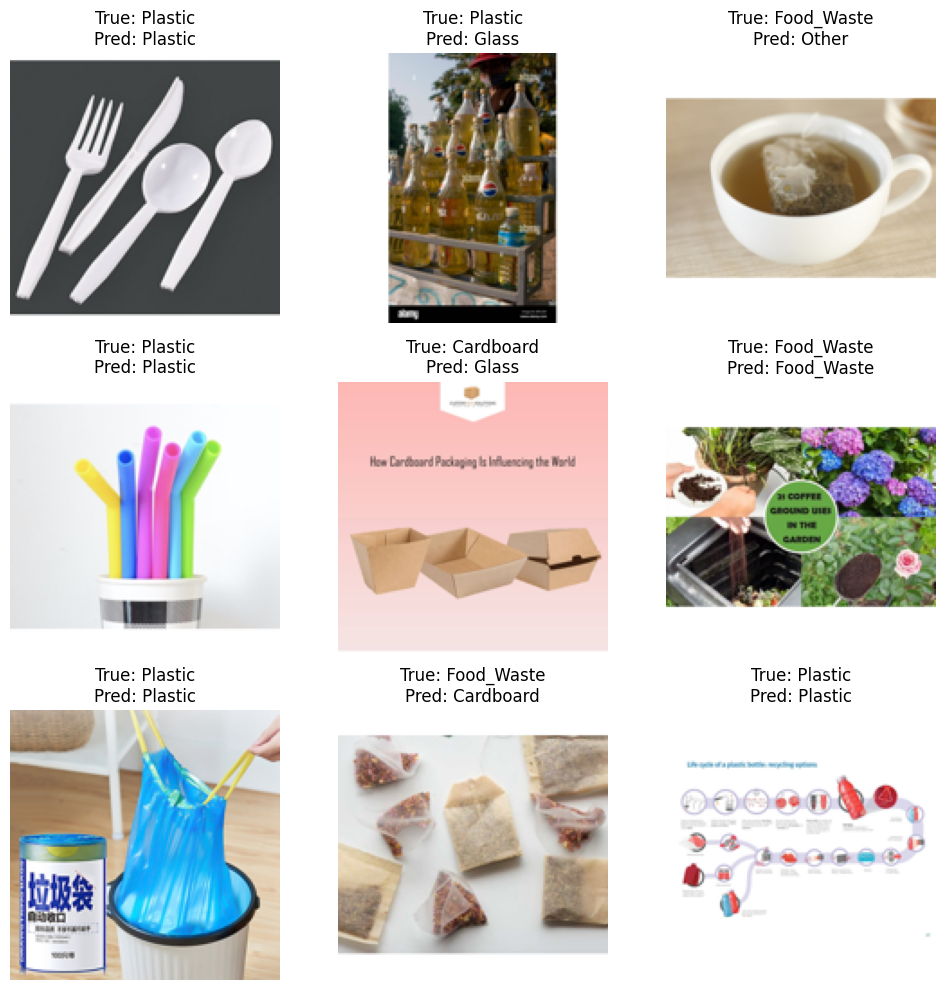

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import random

# Predictions
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report
print(classification_report(y_val, y_pred, target_names=class_names))

# Randomly pick 9 images to visualize predictions on Test Images
indices = random.sample(range(len(X_val)), 9)

plt.figure(figsize=(10,10))

for i, idx in enumerate(indices):
    plt.subplot(3,3,i+1)
    plt.imshow(X_val[idx])

    true_label = class_names[y_val[idx]]
    pred_label = class_names[y_pred[idx]]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

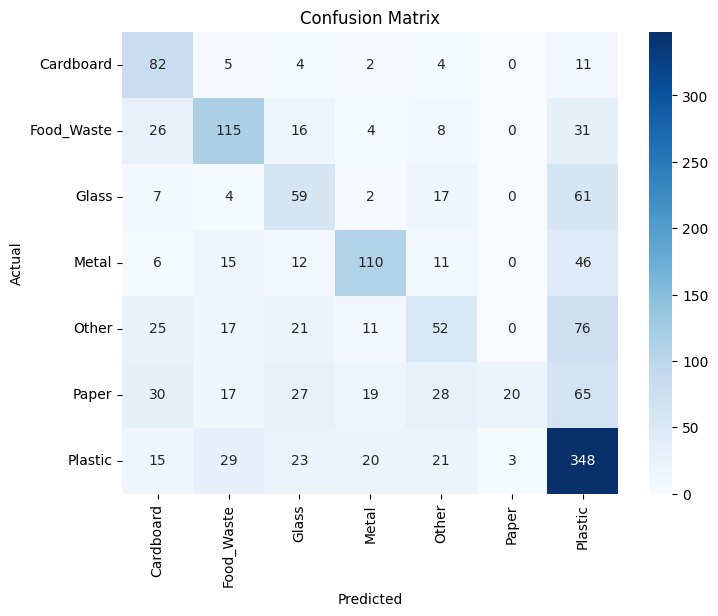

In [18]:
# Confusion matrix
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

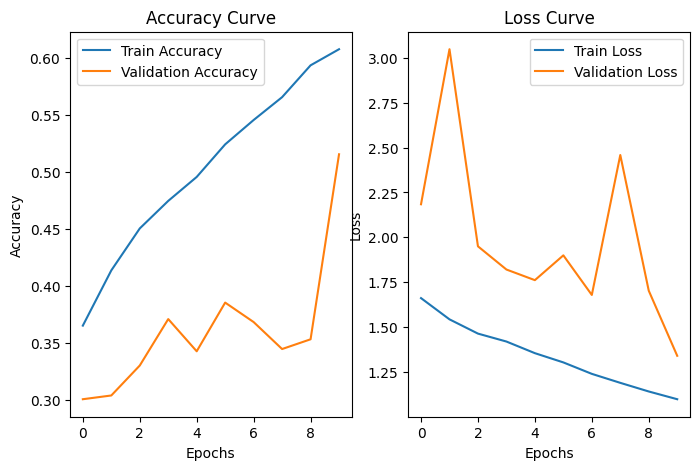

In [19]:
# Accuracy curve

plt.figure(figsize=(8,5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [20]:
# Classification report to understand model performance per class
report_dict = classification_report(
    y_val,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()
df_report

,precision,recall,f1-score,support
Cardboard,0.429319,0.759259,0.548495,108.00000
Food_Waste,0.569307,0.575000,0.572139,200.00000
Glass,0.364198,0.393333,0.378205,150.00000
Metal,0.654762,0.550000,0.597826,200.00000
Other,0.368794,0.257426,0.303207,202.00000
Paper,0.869565,0.097087,0.174672,206.00000
Plastic,0.545455,0.758170,0.634458,459.00000
accuracy,0.515410,0.515410,0.515410,0.51541
macro avg,0.543057,0.484325,0.458429,1525.00000
weighted avg,0.557246,0.515410,0.484202,1525.00000


## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [ ]:
# saving the trained model
model.save("/content/Waste-segregation-CNN-Model.h1")

In [13]:
# Define the Augmentation steps
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1)
])

Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [ ]:
# Create function to augment the images,
MAX_AUG_PER_CLASS = 150  # safe limit

def augment_images_by_class_limited(X, y):
    X_aug, y_aug = [], []

    for class_label in np.unique(y):
        indices = np.where(y == class_label)[0]

        num_to_augment = min(MAX_AUG_PER_CLASS, len(indices))

        sampled_indices = np.random.choice(indices, num_to_augment, replace=True)

        for idx in sampled_indices:
            img = X[idx]
            img = tf.expand_dims(img, axis=0)
            aug_img = data_augmentation(img, training=True)

            X_aug.append(aug_img[0].numpy())
            y_aug.append(class_label)

    return np.array(X_aug), np.array(y_aug)

In [ ]:
# Create the augmented training dataset
# Get class counts
unique, counts = np.unique(y_train, return_counts=True)
class_counts = dict(zip(unique, counts))

print("Original distribution:", class_counts)

# Generate augmented samples
X_aug, y_aug = augment_images_by_class_limited(X_train, y_train)

print("Augmented samples:", len(X_aug))

# Combine
X_train_balanced = np.concatenate([X_train, X_aug], axis=0)
y_train_balanced = np.concatenate([y_train, y_aug], axis=0)

print("Final dataset:", X_train_balanced.shape)

Original distribution: {np.int64(0): np.int64(432), np.int64(1): np.int64(800), np.int64(2): np.int64(600), np.int64(3): np.int64(800), np.int64(4): np.int64(808), np.int64(5): np.int64(824), np.int64(6): np.int64(1836)}
Augmented samples: 1050
Final dataset: (7150, 150, 150, 3)


In [ ]:
# Create the augmented training dataset

# Improved CNN model
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Rescaling(1./255),

    # Augmentation inside model
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    # Block 4
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    # Feature aggregation
    layers.GlobalAveragePooling2D(),

    # Dense
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 148, 148, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 74, 74, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 74, 74, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 36, 36, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 34, 34, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 17, 17, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 684,711 (2.61 MB)

 Trainable params: 683,239 (2.61 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print("Original:", X_train.shape)
print("Augmented:", X_aug.shape)
print("Final:", X_train_balanced.shape)

Original: (6100, 150, 150, 3)
Augmented: (1050, 150, 150, 3)
Final: (7150, 150, 150, 3)


##### **4.1.2**

Train the model on the new augmented dataset.

In [ ]:
# Train the model using augmented images
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

history = model.fit(
    X_train_balanced, y_train_balanced,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 39s 127ms/step - accuracy: 0.2829 - loss: 2.0837 - val_accuracy: 0.0984 - val_loss: 2.1825 - learning_rate: 3.0000e-04
Epoch 2/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 26s 117ms/step - accuracy: 0.3091 - loss: 1.9220 - val_accuracy: 0.1148 - val_loss: 2.6108 - learning_rate: 3.0000e-04
Epoch 3/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 26s 116ms/step - accuracy: 0.3386 - loss: 1.7975 - val_accuracy: 0.2813 - val_loss: 1.9337 - learning_rate: 3.0000e-04
Epoch 4/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 26s 116ms/step - accuracy: 0.3561 - loss: 1.7380 - val_accuracy: 0.2970 - val_loss: 1.9844 - learning_rate: 3.0000e-04
Epoch 5/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 26s 116ms/step - accuracy: 0.3670 - loss: 1.7014 - val_accuracy: 0.3410 - val_loss: 1.7240 - learning_rate: 3.0000e-04
Epoch 6/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 26s 116ms/step - accuracy: 0.3814 - loss: 1.6663 - val_accuracy: 0.3607 - val_loss: 1.7153 - learning_rate: 3.0000e-04
Epoch 7/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 26s 11

In [16]:
# same code used MobilenetV2 with transfer learning which boosted the accuracy to 85%

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./255),
    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 402s 2s/step - accuracy: 0.4639 - loss: 1.6447 - val_accuracy: 0.7036 - val_loss: 0.8476
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.6048 - loss: 1.1640 - val_accuracy: 0.7364 - val_loss: 0.7028
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 412s 2s/step - accuracy: 0.6541 - loss: 1.0201 - val_accuracy: 0.7541 - val_loss: 0.6648
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.6761 - loss: 0.9121 - val_accuracy: 0.7744 - val_loss: 0.6205
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 456s 2s/step - accuracy: 0.6995 - loss: 0.8577 - val_accuracy: 0.7836 - val_loss: 0.5893
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.7089 - loss: 0.8091 - val_accuracy: 0.7902 - val_loss: 0.5757
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.7197 - loss: 0.7958 - val_accuracy: 0.7961 - val_loss: 0.5713
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.7416 - loss: 0.7399 - val_accu

## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results

* Report you findins about the data

1. Data set Overview

  * The dataset consitse of 7 waste categories
    * Cardboard, Food waste, Glass, Metal, Other, Paper, Plastic
  * Total samples: ~7600 + images
  * All images are RGB and uniform in size (256 x 256)

2. Class Imbalance
  * Some classes (e.g Plastic, Paper) have more samples
  * Other (e.g Metal, other) have fewer samples
  
  This can lead to:
  * Bias toward dominant classes
  * Misclassification of minority classes

3. Visual similarity between classes
  * Certain categories share similar featuresL
    * Paper vs Cardboar
    * Plastic vs Glass
    * Metal vs Other

Makes classification challenging for the model

4. Presence of noise
  * Some images appear irrelevant or ambiguous (especially in 'Other' class)
  * This can reduce model accuracy

5. Data distribution insight
 * Dataset is initially ordered by class
 * Requires proper shuffling during training to avoid bias


 Conclusion
 * The dataset is well structured and sufficient for training
 * However, challenges include
   *  class imbalace
   * Inter class similarity
   * Noisy samples

These factors impact model performance and justify the use of
* Data augmentation
* Transfer learning


* Report model training results

### Model Training summary
* Baseline CNN Model
* Training Accuracy: ~50 - 60%
* Validation Accuracy: ~40-45%
* Observations:
  * Model showed limited learning capacity
  * Slight underfitting
  * Struggled to differentiate between similar classes

### CNN with Data Augmentation
* Training accuracy: ~48 to 60%
* Validation Accuracy: ~40%
* Observations:
  * Augmentation improved generalization slightly
  * However, no significant accuracy gain
  * Model still underperformed due to limited complexity

### Transfer Learning Model (MobileNetV2)
* Training Accuracy: ~85%
* Vaidation Accuracy: ~84%
* Vaidation loss: ~0.50

### Key Improvements
* Significant performance boost from ~50% to 85%
* Faster convergence due to pretrained features
* Stable training wiht minimal overfitting
* Better handling of
  * Class imblance
  * Visual similarity between categories


### Observation from Training
* Accuracy improved steadily across epochs
* Validation accuracy closely followed training accuracy
  * indicate good generalization
* Peak performance achieved around epoch 8 - 9


### Conclusion
* The baseline CNN model provided moderate performance
* Data augmentation alone was not sufficient
* Transfer learning significantly improved results, making the model robust
and reliable for classification

* Transfer learning proved to be the most effective approach, leveraging pretrained knowledge to achieve high accuracy and stable performance compared to traditional CNN models